# Notebook exploration donnees au stations


In [1]:
# importations

import xarray as xr
import pandas as pd
import numpy as np
import glob
import os
from tqdm import tqdm
import xclim as xc
import matplotlib.pyplot as plt
from cartopy import crs as ccrs
from cartopy import feature as cfeature



In [2]:
# lecture des données

f1 = "/gpfs/home/dm4482/1_projets/202505_donnees_station_snap/data/snap/quotid/tasmin_avec_code_qualite/1950_2019.nc"
f2 = "/gpfs/home/dm4482/1_projets/202505_donnees_station_snap/data/snap/quotid/tasmin_avec_code_qualite/2020_2024.nc"

ds1 = xr.open_dataset(f1)
ds2 = xr.open_dataset(f2)
ds = xr.open_mfdataset([f1, f2])
da = ds["tasmin"]
da.load()
da
da_ori = da.copy()
    
 

valeurs aberrantes: [-60, 50]
nombre de valeurs aberrantes: 0
nombre de stations avec valeurs aberrantes: 0
code des valeurs aberrantes: []
valeurs louches: [-50, 30]
nombre de valeurs louches: 34
nombre de stations avec valeurs louches: 19
code des valeurs louches: [ 2. nan]


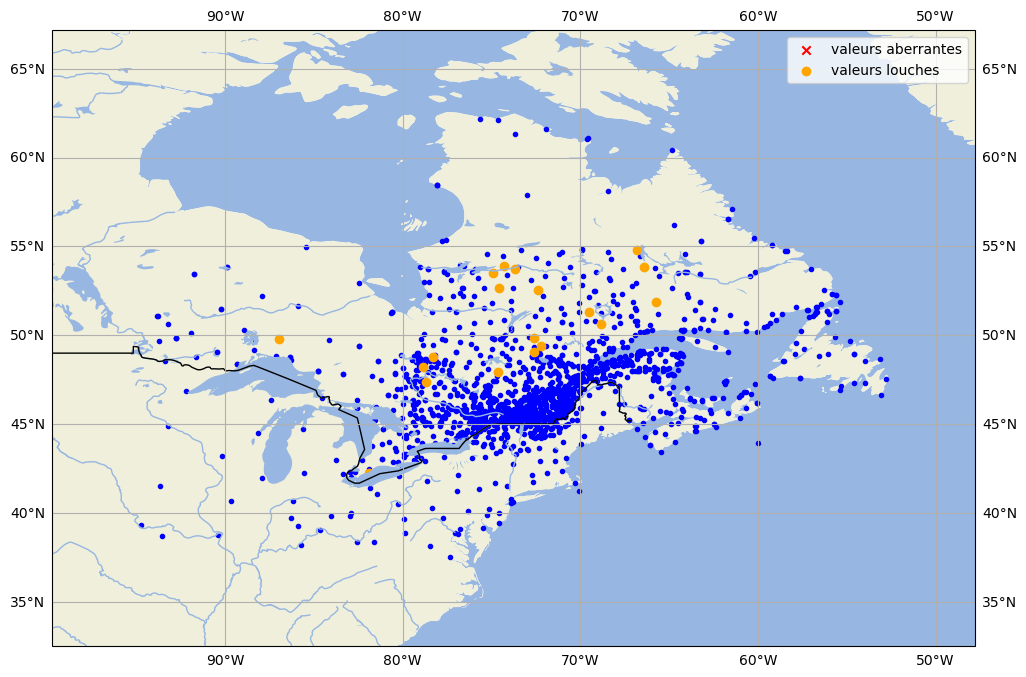

In [3]:
# affichage de la position des stations

# on masque les données mauvaises
da = da_ori.where(da_ori.code_qualite !=7)
# on génere des flags aberrant et louche
val_ab = [-60, 50]
val_lo = [-50, 30]
flag_ab = (da < val_ab[0]) | (da > val_ab[1])
flag_lo = (da < val_lo[0]) | (da > val_lo[1])

from cartopy import crs as ccrs
from cartopy import feature as cfeature
import matplotlib.pyplot as plt
projection=ccrs.PlateCarree()

dlon = 5
dlat = 5
lllon = da.lon.min() - dlon
urlon = da.lon.max() + dlon
lllat = da.lat.min() - dlat
urlat = da.lat.max() + dlat

# on fait la figure
fig = plt.figure(figsize=(12, 8))
nx = 1
ny = 1
ax = fig.add_subplot(ny, nx, 1, projection=projection)
ax.set_extent([lllon, urlon, lllat, urlat], crs=projection)
# ax.set_extent([-85, -80, 40, 45], crs=projection)
# plt.scatter(-73,45, marker="*", color="red", s=100, label="Montreal")
plt.scatter(da.lon.values, da.lat.values, color="blue", marker=".")

# details de la carte affichee
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.LAKES)
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.BORDERS)
ax.gridlines(draw_labels=True)


# affichage des stations avec données aberrantes
print(f"valeurs aberrantes: {val_ab}")
da_ab = da.where(flag_ab, drop=True)
plt.scatter(da_ab.lon.values, da_ab.lat.values, color="red", marker="x", label="valeurs aberrantes", zorder=10)
print(f"nombre de valeurs aberrantes: {da_ab.count().values}")
print(f"nombre de stations avec valeurs aberrantes: {da_ab.stn.size}")
code_ab = da_ab.code_qualite.where(~da_ab.isnull()).values
print(f"code des valeurs aberrantes: {np.unique(code_ab)}")

# affichage des stations avec données louches
print(f"valeurs louches: {val_lo}")
da_louches = da.where(flag_lo &  ~flag_ab, drop=True)
plt.scatter(da_louches.lon.values, da_louches.lat.values, color="orange", marker="o", label="valeurs louches")
print(f"nombre de valeurs louches: {da_louches.count().values}")
print(f"nombre de stations avec valeurs louches: {da_louches.stn.size}")
code_louches = da_louches.code_qualite.where(~da_louches.isnull()).values
print(f"code des valeurs louches: {np.unique(code_louches)}")


plt.legend()
plt.show()




In [4]:
# affichage des stations avec des valeurs louches
import numpy as np

for stn in da_louches.stn.values:
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    da_stn_lo = da_louches.sel(stn=stn).dropna("time")
    time_min = da_stn_lo.time.min() - np.timedelta64(10, "D")
    time_max = da_stn_lo.time.max() + np.timedelta64(10, "D")
    da_stn = da.sel(stn=stn, time=slice(time_min, time_max))
    da_stn.plot()
    flag_lo_stn = flag_lo.sel(stn=stn, time=slice(time_min, time_max))
    da_stn.where(flag_lo_stn).plot(marker="o", markersize=2, linewidth=0.5)
    nom_station = da_stn.nom_station.values.item()
    titre = f"Station {stn} {nom_station}"
    ax.set_title(titre)
    plt.savefig(f"../fig/valeur_louche_tasmin_{stn}_{nom_station}.png")
    plt.close()

    # plt.show()

    # print des dates avec évenement louches
    print(f"Station {da_stn.nom_station.values.item()}")
    tampon = da_stn.where(flag_lo_stn, drop=True)
    for tt in tampon.time.values:
        # Conversion en chaîne formatée
        formatted_date = np.datetime_as_string(tt, unit='D')  # Format avec précision au jour
        val = da_stn.sel(time=tt).values.item()
        print(f"valeur louche : {val} le {formatted_date}")
    
    


Station Parent (CWPK)
valeur louche : -51.2 le 1955-02-02
Station Lac Liberal (CQLL)
valeur louche : 36.3 le 2000-04-19
Station Misask (CMHC)
valeur louche : -51.7 le 2023-02-24
valeur louche : -51.0 le 2023-02-25
Station Erieau (CWAJ)
valeur louche : 33.2 le 2022-09-27
valeur louche : 48.6 le 2023-04-20
valeur louche : 45.5 le 2023-04-22
valeur louche : 46.4 le 2023-04-23
valeur louche : 48.9 le 2023-04-24
Station Riviere aux Rats (7066583)
valeur louche : -50.6 le 1972-02-24
Station Schefferville A (7117825)
valeur louche : -50.6 le 1950-02-08
Station Lac Berry (709CEE9)
valeur louche : -50.5 le 1981-01-04
Station La Grande IV A (CYAH)
valeur louche : -50.4 le 2003-02-15
valeur louche : -50.3 le 2004-01-15
Station Kinojevis (7086630)
valeur louche : -51.0 le 1982-01-18
valeur louche : -52.0 le 1982-01-19
Station Poste Montagnais (7046212)
valeur louche : -51.0 le 2002-01-31
Station Esker 2 (8501548)
valeur louche : -51.2 le 1973-02-18
Station Manicouagan A (7044470)
valeur louche : -

In [5]:
# sauvegarde d'une caret interactive des stations dans un fichier html que je peux copier sur mon portable et ouvrir avec Chrome
import folium

# Create a map centered around the average latitude and longitude of the stations
center_lat = da.lat.mean().item()
center_lon = da.lon.mean().item()
m = folium.Map(location=[center_lat, center_lon], zoom_start=5)

# Add markers for each station
for stn, lat, lon in zip(da.stn.values, da.lat.values, da.lon.values):
    if not np.isnan(lat) and not np.isnan(lon):  # Ensure valid coordinates
        folium.Marker(
            location=[lat, lon],
            popup=f"Station ID: {stn}",
        ).add_to(m)

# Display the map
m.save("stations_map.html")


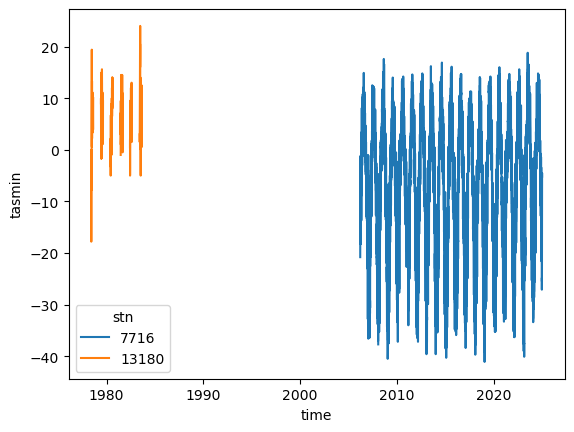

In [6]:
# affichage de séries temporelles pour certaines stations

l1_stn = [7256, 15839]
l2_stn = [7716, 13180]

dar = da.sel(stn=da.stn.isin(l2_stn))
dar.plot.line(hue="stn")


## filtrage des stations


In [7]:
# on tente de filtrer les stations pour rejeter celles qui causes des problèmes

# lecture des données

f1 = "/gpfs/home/dm4482/1_projets/202505_donnees_station_snap/data/snap/quotid/tasmin_avec_code_qualite/1950_2019.nc"
f2 = "/gpfs/home/dm4482/1_projets/202505_donnees_station_snap/data/snap/quotid/tasmin_avec_code_qualite/2020_2024.nc"

ds1 = xr.open_dataset(f1)
ds2 = xr.open_dataset(f2)
ds = xr.open_mfdataset([f1, f2])
da = ds["tasmin"]
da.load()

da


<xarray.DataArray 'tasmin' (time: 27394, stn: 1614)> Size: 354MB
array([[  nan,   nan,   nan, ...,   nan,   nan,   nan],
       [  nan,   nan,   nan, ...,   nan,   nan,   nan],
       [  nan,   nan,   nan, ...,   nan,   nan,   nan],
       ...,
       [  nan,  -8.6, -11.1, ...,   nan,   nan,   nan],
       [  nan,  -4. ,  -1.9, ...,   nan,   nan,   nan],
       [  nan,  -3.3,   2.9, ...,   nan,   nan,   nan]],
      shape=(27394, 1614))
Coordinates:
  * stn           (stn) int32 6kB 2907 2934 3093 3094 ... 15961 15962 15963
  * time          (time) datetime64[ns] 219kB 1950-01-01 ... 2024-12-31
    id_station    (stn) float64 13kB 2.907e+03 2.934e+03 ... 1.596e+04 1.596e+04
    nom_station   (stn) object 13kB 'Laforge-2 KD-04 (CQDK)' ... 'Glen Afton'
    lon           (stn) float64 13kB -71.04 -66.92 -72.92 ... -80.45 -80.0 -80.3
    lat           (stn) float64 13kB 54.67 50.78 46.18 ... 46.57 46.11 46.95
    alt           (stn) float64 13kB 478.0 521.0 16.2 9.5 ... nan nan nan nan
    id_analog     (stn) float64 13kB 1.846e+05 1.281e+05 ... 6.483e+05 6.482e+05
    code_qualite  (stn, time) float64 354MB nan nan nan nan ... 1.0 1.0 1.0 1.0

In [ ]:
# on regarde les mois considérés comme incomplet selon le critère de la WMO
# *** prend beaucoup de temps ***

mask_wmo = xc.core.missing.missing_wmo(da, "MS")


nb stations totales : 1614
nb stations valides : 884
nb stations rejetees : 730


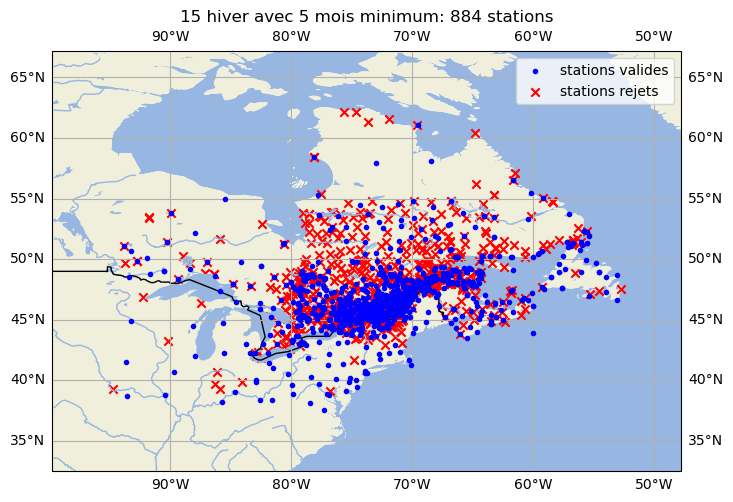

In [47]:
# on regarde les stations qui repondent a certains critères
l_mois_saison_froide = [1, 2, 3, 11, 12]
nb_mois_saison_froide = 5
nb_saison_froide_min =15
nb_mois_valides_saison_froide = (~mask_wmo.sel(time=mask_wmo.time.dt.month.isin(l_mois_saison_froide))*1.).resample(time="YS-AUG").sum()
nb_saison_froide_valide = (nb_mois_valides_saison_froide >= nb_mois_saison_froide).sum(dim="time")
stn_valides = nb_saison_froide_valide.where(nb_saison_froide_valide >= nb_saison_froide_min, drop=True).stn
stn_valides
stn_rejets = da.where(~da.stn.isin(stn_valides), drop=True).stn
print(f"nb stations totales : {da.stn.size}")
print(f"nb stations valides : {stn_valides.size}")
print(f"nb stations rejetees : {stn_rejets.size}")
# print(da.stn)
# print(stn_valides)

# # verif pour une station en particulier
# stn_verif = 7716
# print(stn_verif in stn_valides.values)
# nb_mois_valides_saison_froide.sel(stn=stn_verif).plot()
# print(nb_saison_froide_valide.sel(stn=stn_verif).values)
# plt.show()

# on fait la figure de stations totales et retenues
projection=ccrs.PlateCarree()
dlon = 5
dlat = 5
lllon = da.lon.min() - dlon
urlon = da.lon.max() + dlon
lllat = da.lat.min() - dlat
urlat = da.lat.max() + dlat

fig = plt.figure(figsize=(16, 12))
nx = 1
ny = 2
ax = fig.add_subplot(ny, nx, 1, projection=projection)
ax.set_extent([lllon, urlon, lllat, urlat], crs=projection)
# ax.set_extent([-85, -80, 40, 45], crs=projection)
# plt.scatter(-73,45, marker="*", color="red", s=100, label="Montreal")
plt.scatter(stn_valides.lon.values, stn_valides.lat.values, color="blue", marker=".", label="stations valides", zorder=3)
plt.scatter(stn_rejets.lon.values, stn_rejets.lat.values, color="red", marker="x", label="stations rejets")

# details de la carte affichee
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.LAKES)
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.BORDERS)
ax.gridlines(draw_labels=True)

titre = f"{nb_saison_froid_min} hiver avec {nb_mois_saison_froide} mois minimum: {stn_valides.size} stations"
ax.set_title(titre)

plt.legend()
plt.show()

# print(stn_valides.stn.to_dataframe().index.reset_index())
df = pd.Series(stn_valides.stn.values, name="stn")
df.to_csv(f"stations_valides_{nb_saison_froide_min}_ans_{nb_mois_saison_froide}_mois.csv", index=False)


In [46]:
# on genere les masque quotid a partir de masques mensuels
mask_wmo_quotid = mask_wmo.resample(time="D").ffill()
mask_wmo_quotid
# da

<xarray.DataArray (time: 27364, stn: 1614)> Size: 44MB
array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True, False, False, ...,  True,  True,  True],
       [ True, False, False, ...,  True,  True,  True],
       [ True, False, False, ...,  True,  True,  True]],
      shape=(27364, 1614))
Coordinates:
  * time         (time) datetime64[ns] 219kB 1950-01-01 ... 2024-12-01
  * stn          (stn) int32 6kB 2907 2934 3093 3094 ... 15852 15961 15962 15963
    id_station   (stn) float64 13kB 2.907e+03 2.934e+03 ... 1.596e+04 1.596e+04
    nom_station  (stn) object 13kB 'Laforge-2 KD-04 (CQDK)' ... 'Glen Afton'
    lon          (stn) float64 13kB -71.04 -66.92 -72.92 ... -80.45 -80.0 -80.3
    lat          (stn) float64 13kB 54.67 50.78 46.18 ... 46.57 46.11 46.95
    alt          (stn) float64 13kB 478.0 521.0 16.2 9.5 ... nan nan nan nan
    id_analog    (stn) float64 13kB 1.846e+05 1.281e+05 ... 6.483e+05 6.482e+05

In [26]:
import xarray as xr
import pandas as pd
from xclim.core.missing import missing_wmo

# Exemple de création d'un DataArray avec des données journalières
time = pd.date_range("2023-01-01", "2023-01-10", freq="D")
data = xr.DataArray([1, 2, None, 4, 5, None, 7, 8, 9, None], coords={"time": time}, dims=["time"])

# Appliquer le masque WMO pour les données manquantes
wmo_mask = missing_wmo(data, freq="D")

# Masquer les données identifiées comme manquantes
masked_data = data.where(~wmo_mask)

# Afficher les données masquées
print(masked_data)

ValueError: The target resampling frequency cannot be finer than the first-step frequency. Got : MS > D.

In [15]:
mois_incomplet.sel(stn=13180).time



<xarray.DataArray 'time' (time: 900)> Size: 7kB
array(['1950-01-01T00:00:00.000000000', '1950-02-01T00:00:00.000000000',
       '1950-03-01T00:00:00.000000000', ..., '2024-10-01T00:00:00.000000000',
       '2024-11-01T00:00:00.000000000', '2024-12-01T00:00:00.000000000'],
      shape=(900,), dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 ... 2024-12-01
    stn          int32 4B 13180
    id_station   float64 8B 1.318e+04
    nom_station  object 8B 'Duplanter (7112249)'
    lon          float64 8B -69.88
    lat          float64 8B 54.83
    alt          float64 8B nan
    id_analog    float64 8B 6.016e+05

In [19]:
# suggestion de gemini
from xclim.core.indicator import Indicator

# Define a simple indicator
class MyIndicator(Indicator):
    identifier = "my_indicator"
    def compute(self, da):
        return da.copy()

# Use missing_wmo with the indicator
with xc.set_options(check_missing="wmo"):
    indicator = MyIndicator(realm="atmos")
    da_masque = indicator(da=da)

# Print the results
print("Original Data:")
print(da)
print("\nData masked with missing_wmo:")
print(da_masque)

TypeError: got an unexpected keyword argument 'da'

In [20]:
import xarray as xr
import xclim
from xclim.core.indicator import Indicator
import numpy as np

# Create some sample daily data with missing values
time = xr.cftime_range("2000-01-01", "2000-01-31", freq="D")
data = np.random.rand(len(time))
data[5:10] = np.nan  # Introduce some consecutive missing values
data[15] = np.nan  # Introduce a single missing value
data_array = xr.DataArray(data, coords=[time], dims=["time"])

# Define a simple indicator
class MyIndicator(Indicator):
    identifier = "my_indicator"
    def compute(self, da):
        return da.copy()

# Use missing_wmo with the indicator
with xclim.set_options(check_missing="wmo"):
    indicator = MyIndicator()
    masked_data = indicator(da=data_array)

# Print the results
print("Original Data:")
print(data_array)
print("\nData masked with missing_wmo:")
print(masked_data)

/tmp/ipykernel_1257621/3406042223.py:7: DeprecationWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  time = xr.cftime_range("2000-01-01", "2000-01-31", freq="D")


AttributeError: Indicator's realm must be given as one of 'atmos', 'seaIce', 'land', 'ocean' or 'generic'